<a href="https://colab.research.google.com/github/Nisarga25/ML_2_063/blob/main/candidate_elimination(063).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CANDIDATE ELIMINATION ALGORITHM

Dataset: Loan Approval Eligibility
Attributes: ['CreditScore', 'Income', 'Employment', 'LoanAmount']

Example 1: ['High', 'High', 'Stable', 'Low']
Classification: Yes
Positive Example Processed
S Boundary: [['High', 'High', 'Stable', 'Low']]
G Boundary: [['?', '?', '?', '?']]

Example 2: ['High', 'High', 'Stable', 'Medium']
Classification: Yes
Positive Example Processed
S Boundary: [['High', 'High', 'Stable', '?']]
G Boundary: [['?', '?', '?', '?']]

Example 3: ['Low', 'Low', 'Unstable', 'High']
Classification: No
Negative Example Processed
S Boundary: [['High', 'High', 'Stable', '?']]
G Boundary: [['High', '?', '?', '?'], ['?', 'High', '?', '?'], ['?', '?', 'Stable', '?']]

Example 4: ['High', 'Medium', 'Stable', 'Low']
Classification: Yes
Positive Example Processed
S Boundary: [['High', '?', 'Stable', '?']]
G Boundary: [['High', '?', '?', '?'], ['?', '?', 'Stable', '?']]

Example 5: ['Medium', 'Low', 'Stable', 'High']
Classification: No
Negative Examp

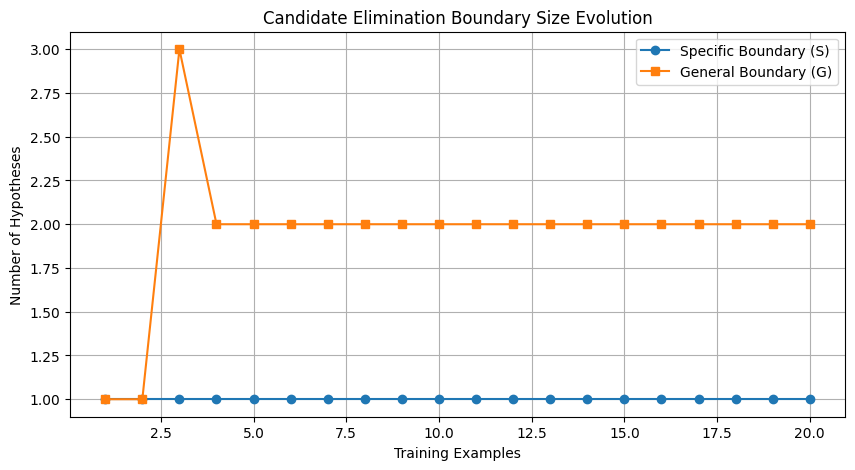

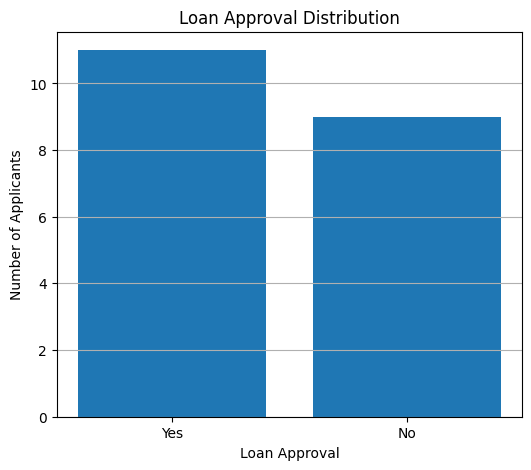


LOAN APPROVAL DATASET
CreditScore Income Employment LoanAmount LoanApproved
       High   High     Stable        Low          Yes
       High   High     Stable     Medium          Yes
        Low    Low   Unstable       High           No
       High Medium     Stable        Low          Yes
     Medium    Low     Stable       High           No
       High   High     Stable        Low          Yes
        Low Medium   Unstable       High           No
       High   High     Stable     Medium          Yes
     Medium    Low   Unstable     Medium           No
       High Medium     Stable       High          Yes
        Low    Low   Unstable        Low           No
       High   High     Stable        Low          Yes
     Medium Medium   Unstable       High           No
       High   High     Stable     Medium          Yes
        Low Medium     Stable       High           No
       High Medium     Stable       High          Yes
     Medium    Low   Unstable        Low           No
     

In [1]:
# ============================================================
# CANDIDATE ELIMINATION ALGORITHM
# Dataset: Loan Approval Eligibility (20 Records)
# With Visualization Graphs
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. DATASET
# ============================================================

attributes = ['CreditScore', 'Income', 'Employment', 'LoanAmount']

data = [
    ['High',   'High',   'Stable',   'Low',    'Yes'],
    ['High',   'High',   'Stable',   'Medium', 'Yes'],
    ['Low',    'Low',    'Unstable', 'High',   'No'],
    ['High',   'Medium', 'Stable',   'Low',    'Yes'],
    ['Medium', 'Low',    'Stable',   'High',   'No'],
    ['High',   'High',   'Stable',   'Low',    'Yes'],
    ['Low',    'Medium', 'Unstable', 'High',   'No'],
    ['High',   'High',   'Stable',   'Medium', 'Yes'],
    ['Medium', 'Low',    'Unstable', 'Medium', 'No'],
    ['High',   'Medium', 'Stable',   'High',   'Yes'],
    ['Low',    'Low',    'Unstable', 'Low',    'No'],
    ['High',   'High',   'Stable',   'Low',    'Yes'],
    ['Medium', 'Medium', 'Unstable', 'High',   'No'],
    ['High',   'High',   'Stable',   'Medium', 'Yes'],
    ['Low',    'Medium', 'Stable',   'High',   'No'],
    ['High',   'Medium', 'Stable',   'High',   'Yes'],
    ['Medium', 'Low',    'Unstable', 'Low',    'No'],
    ['High',   'High',   'Stable',   'Low',    'Yes'],
    ['Low',    'Low',    'Unstable', 'Medium', 'No'],
    ['High',   'High',   'Stable',   'Medium', 'Yes']
]

X = [row[:-1] for row in data]
y = [row[-1] for row in data]

n_attributes = len(attributes)


# ============================================================
# 2. CANDIDATE ELIMINATION ALGORITHM
# ============================================================

# Initialize S boundary with most specific hypothesis
S = [['Ø'] * n_attributes]

# Initialize G boundary with most general hypothesis
G = [['?'] * n_attributes]


# Store boundary sizes for graph
s_history = []
g_history = []


# ============================================================
# FUNCTION TO CHECK IF HYPOTHESIS COVERS AN EXAMPLE
# ============================================================

def covers(hypothesis, example):

    for h, x in zip(hypothesis, example):

        if h == '?':
            continue

        elif h == 'Ø':
            return False

        elif h != x:
            return False

    return True


# ============================================================
# FUNCTION TO GENERALIZE HYPOTHESIS
# ============================================================

def generalize(hypothesis, example):

    new_hypothesis = hypothesis.copy()

    for i in range(len(hypothesis)):

        if hypothesis[i] == 'Ø':
            new_hypothesis[i] = example[i]

        elif hypothesis[i] != example[i]:
            new_hypothesis[i] = '?'

    return new_hypothesis


# ============================================================
# 3. RUN CANDIDATE ELIMINATION
# ============================================================

print("=" * 70)
print("CANDIDATE ELIMINATION ALGORITHM")
print("=" * 70)

print("\nDataset: Loan Approval Eligibility")
print("Attributes:", attributes)


for index, (example, label) in enumerate(zip(X, y), start=1):

    print(f"\nExample {index}: {example}")
    print(f"Classification: {label}")


    # --------------------------------------------------------
    # POSITIVE EXAMPLE
    # --------------------------------------------------------

    if label == 'Yes':

        new_S = []

        for hypothesis in S:

            if not covers(hypothesis, example):

                generalized = generalize(hypothesis, example)

                new_S.append(generalized)

            else:

                new_S.append(hypothesis)

        S = new_S


        # Remove hypotheses from G
        # that don't cover positive example

        G = [
            hypothesis for hypothesis in G
            if covers(hypothesis, example)
        ]

        print("Positive Example Processed")


    # --------------------------------------------------------
    # NEGATIVE EXAMPLE
    # --------------------------------------------------------

    else:

        new_G = []

        for hypothesis in G:

            # If hypothesis covers negative example,
            # specialize it

            if covers(hypothesis, example):

                for i in range(n_attributes):

                    if hypothesis[i] == '?':

                        # Create specialization using S boundary

                        if S[0][i] != '?' and S[0][i] != 'Ø':

                            new_hypothesis = hypothesis.copy()

                            new_hypothesis[i] = S[0][i]

                            if new_hypothesis not in new_G:

                                new_G.append(new_hypothesis)

            else:

                new_G.append(hypothesis)


        if new_G:

            G = new_G

        print("Negative Example Processed")


    # Store boundary sizes

    s_history.append(len(S))
    g_history.append(len(G))


    print("S Boundary:", S)
    print("G Boundary:", G)


# ============================================================
# 4. DISPLAY FINAL BOUNDARIES
# ============================================================

print("\n" + "=" * 70)
print("FINAL SPECIFIC BOUNDARY (S)")
print("=" * 70)

for hypothesis in S:

    print(hypothesis)


print("\n" + "=" * 70)
print("FINAL GENERAL BOUNDARY (G)")
print("=" * 70)

for hypothesis in G:

    print(hypothesis)


# ============================================================
# 5. GRAPH 1 - S AND G BOUNDARY SIZE
# ============================================================

examples = list(range(1, len(data) + 1))

plt.figure(figsize=(10, 5))

plt.plot(
    examples,
    s_history,
    marker='o',
    label='Specific Boundary (S)'
)

plt.plot(
    examples,
    g_history,
    marker='s',
    label='General Boundary (G)'
)

plt.title("Candidate Elimination Boundary Size Evolution")
plt.xlabel("Training Examples")
plt.ylabel("Number of Hypotheses")

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 6. GRAPH 2 - LOAN APPROVAL DISTRIBUTION
# ============================================================

df = pd.DataFrame(
    data,
    columns=[
        'CreditScore',
        'Income',
        'Employment',
        'LoanAmount',
        'LoanApproved'
    ]
)

loan_count = df['LoanApproved'].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(
    loan_count.index,
    loan_count.values
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approval")
plt.ylabel("Number of Applicants")

plt.grid(axis='y')

plt.show()


# ============================================================
# 7. DISPLAY DATASET
# ============================================================

print("\n" + "=" * 70)
print("LOAN APPROVAL DATASET")
print("=" * 70)

print(df.to_string(index=False))